In [37]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [38]:
# Load Dataset

df = pd.read_csv('/content/cleaned_data.csv')

# Display first 5 rows
df.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,no,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,no,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,no,1,0
4,C00005,16,185,1023,One year,Electronic Check,no,1,0


In [39]:
#  --------------- Dataset Overview  -----------------
# Shape of dataset
print("Rows and Columns:", df.shape)

# Dataset information : This shows the columns, datatypes and missing values
df.info()


Rows and Columns: (500, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB


In [40]:
# -------------- Target Variable Analysis ----------------

# Churn count
df['Churn'].value_counts()

# Churn percentage
df['Churn'].value_counts(normalize=True) * 100



,proportion
Churn,
0,89.4
1,10.6


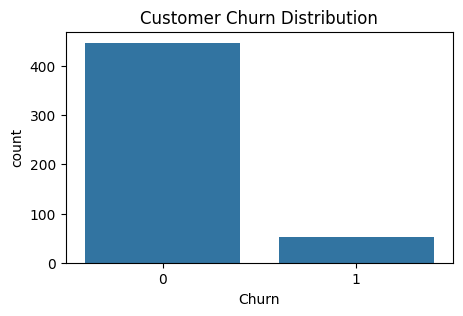

In [41]:
# Visualization
# Churn count plot

plt.figure(figsize=(5,3))
sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.show()

In [42]:
#  ----------------- Numerical Feature Analysis  ------------------
# Numerical columns
numeric_cols = df.select_dtypes(include=np.number).columns
numeric_cols

Index(['Tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn'], dtype='object')

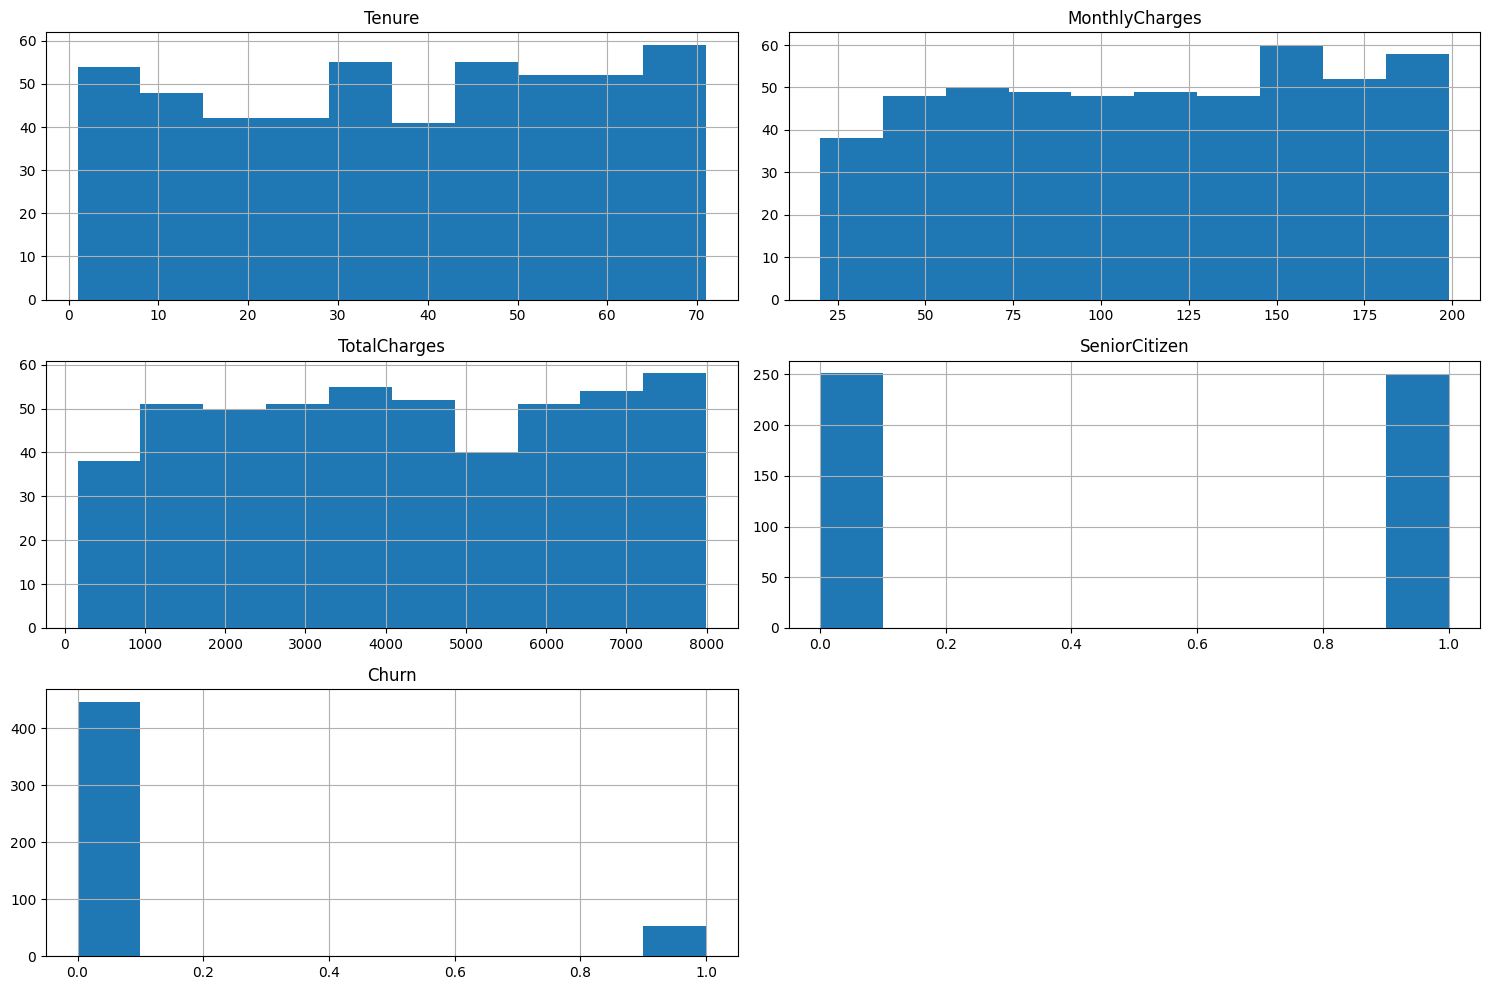

In [43]:
# Histograms: This shows data distribution.
df[numeric_cols].hist(figsize=(15,10))

plt.tight_layout()
plt.show()

In [44]:
# -----------  Correlation Analysis -------------
# Correlation matrix
correlation = df[numeric_cols].corr()
correlation

,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
Tenure,1.000000,-0.059655,-0.005677,-0.040001,-0.509208
MonthlyCharges,-0.059655,1.000000,-0.042280,-0.105695,0.107381
TotalCharges,-0.005677,-0.042280,1.000000,0.016360,0.004250
SeniorCitizen,-0.040001,-0.105695,0.016360,1.000000,-0.018114
Churn,-0.509208,0.107381,0.004250,-0.018114,1.000000


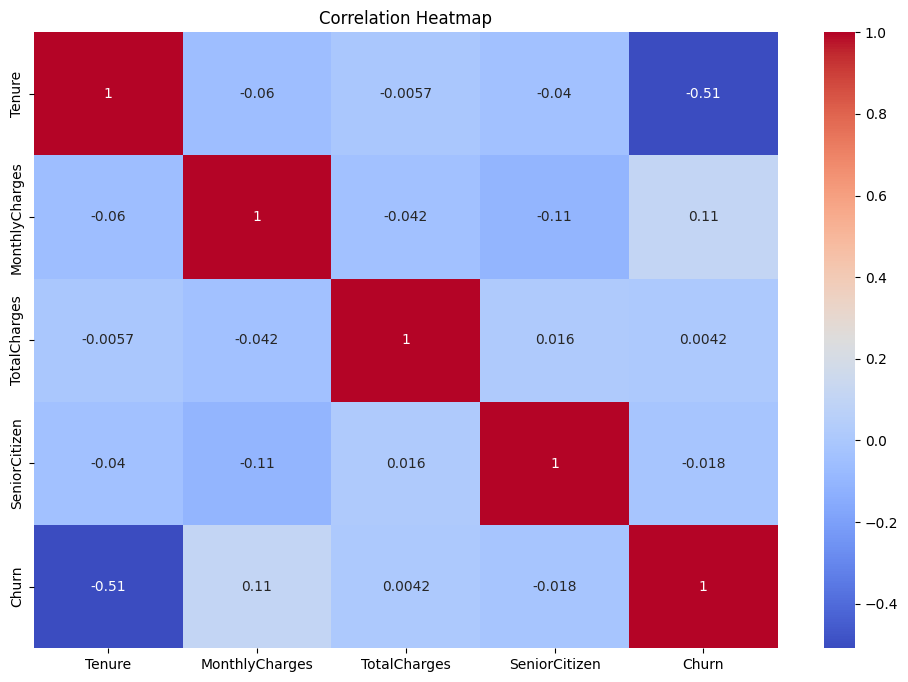

In [45]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

plt.show()

In [46]:
df.columns.tolist()

['CustomerID',
 'Tenure',
 'MonthlyCharges',
 'TotalCharges',
 'Contract',
 'PaymentMethod',
 'PaperlessBilling',
 'SeniorCitizen',
 'Churn']

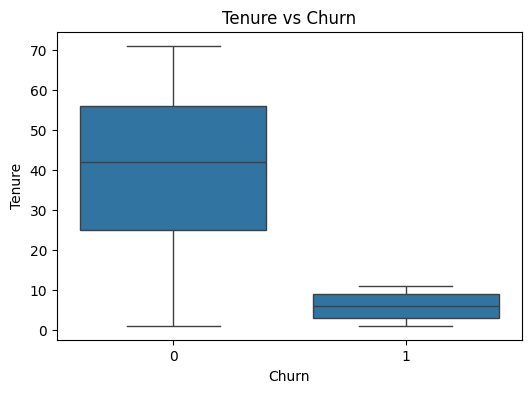

In [47]:
# ------------- Churn vs Numerical Features ---------------

# Tenure vs churn
plt.figure(figsize=(6,4))

sns.boxplot(x='Churn', y='Tenure', data=df)
plt.title('Tenure vs Churn')

plt.show()

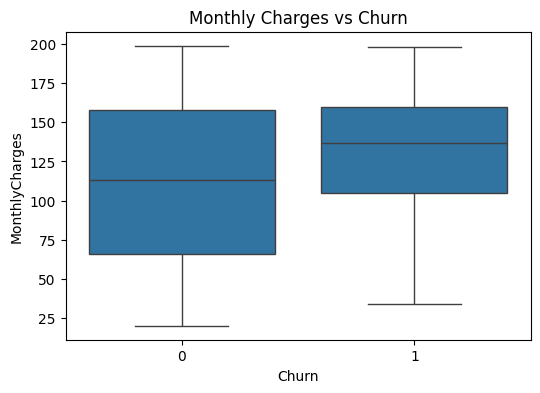

In [48]:
# Monthly charges vs churn
plt.figure(figsize=(6,4))

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')

plt.show()

In [49]:
# -------------- Categorical Feature Analysis -------------------

# Categorical columns
categorical_cols = df.select_dtypes(include='object').columns
categorical_cols

Index(['CustomerID', 'Contract', 'PaymentMethod', 'PaperlessBilling'], dtype='object')

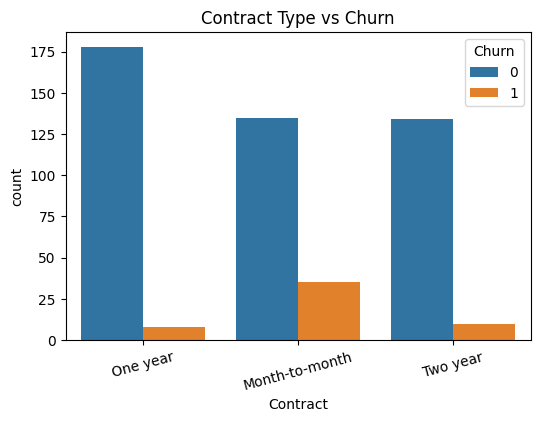

In [50]:
# --------------- Contract Type Analysis -----------------

# Contract type vs churn

plt.figure(figsize=(6,4))

sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Contract Type vs Churn')
plt.xticks(rotation=15)

plt.show()

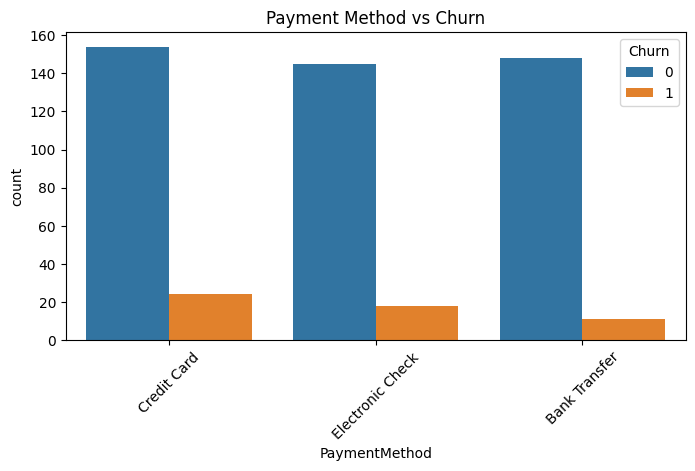

In [51]:
# ---------------- Payment Method Analysis ---------------------
# Payment method vs churn
plt.figure(figsize=(8,4))

sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title('Payment Method vs Churn')
plt.xticks(rotation=45)

plt.show()

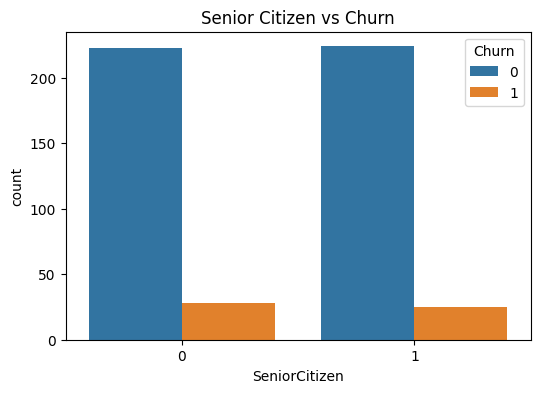

In [52]:
# --------------- Senior citizen Service Analysis ------------------
# Senior citizen churn analysis

plt.figure(figsize=(6,4))

sns.countplot(x='SeniorCitizen', hue='Churn', data=df)

plt.title('Senior Citizen vs Churn')

plt.show()

# -------------------- Business Insights Section -------------------------

### Insight

Customers with month-to-month contracts show significantly higher churn compared to customers with yearly contracts.
This suggests that long-term contracts improve customer retention.


# Key Findings

1. Customers with short tenure are more likely to churn.
2. Month-to-month contracts show highest churn rates.
3. Higher monthly charges are associated with increased churn.
4. Electronic payment users show relatively higher churn.
5. Long-term contract customers have better retention.